In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "DejaVu Sans",
})
 
BLUE   = "#1F6FEB"
GREEN  = "#1D9E75"
CORAL  = "#E05A4E"
AMBER  = "#E09F3E"
GRAY   = "#6B7280"
LIGHT  = "#F3F4F6"

In [3]:
df = pd.read_csv("marketing_AB.csv")

In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
 
print(f"\n  Shape         : {df.shape}")
print(f"  Columns       : {list(df.columns)}")
print(f"\n  Sample rows:\n{df.head(3).to_string(index=False)}")
print(f"\n  Missing values:\n{df.isnull().sum().to_string()}")
print(f"\n  Group distribution:\n{df['test_group'].value_counts().to_string()}")


  Shape         : (588101, 7)
  Columns       : ['unnamed:_0', 'user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']

  Sample rows:
 unnamed:_0  user_id test_group  converted  total_ads most_ads_day  most_ads_hour
          0  1069124         ad      False        130       Monday             20
          1  1119715         ad      False         93      Tuesday             22
          2  1144181         ad      False         21      Tuesday             18

  Missing values:
unnamed:_0       0
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0

  Group distribution:
test_group
ad     564577
psa     23524


# DATA CLEANING & FEATURE ENGINEERING

In [5]:
# Ensure 'converted' is boolean/int
df["converted"] = df["converted"].astype(int)
 
# Map group labels for readability
df["group_label"] = df["test_group"].map({"ad": "Test (Ad)", "psa": "Control (PSA)"})
 
# Segment by ad exposure quartile
df["ad_exposure_quartile"] = pd.qcut(
    df["total_ads"], q=4,
    labels=["Q1 Low", "Q2 Med-Low", "Q3 Med-High", "Q4 High"]
)
 
print(f"\n  Unique groups  : {df['test_group'].unique()}")
print(f"  Converted dtype: {df['converted'].dtype}")
print(f"  No duplicates  : {df.duplicated().sum() == 0}")


  Unique groups  : ['ad' 'psa']
  Converted dtype: int64
  No duplicates  : True


# DESCRIPTIVE STATISTICS

In [6]:
summary = (
    df.groupby("test_group")["converted"]
      .agg(total_users="count", conversions="sum")
      .assign(
          conversion_rate=lambda x: (x["conversions"] / x["total_users"] * 100).round(4),
          non_conversions=lambda x: x["total_users"] - x["conversions"],
      )
)
print(f"\n  Conversion summary:\n{summary.to_string()}")
 
ad_rate  = summary.loc["ad",  "conversion_rate"]
psa_rate = summary.loc["psa", "conversion_rate"]
lift     = ad_rate - psa_rate
rel_lift = (lift / psa_rate * 100).round(2)
 
print(f"\n  Conversion rate — Test  (Ad) : {ad_rate:.4f}%")
print(f"  Conversion rate — Control    : {psa_rate:.4f}%")
print(f"  Absolute lift                : +{lift:.4f} pp")
print(f"  Relative lift                : +{rel_lift:.2f}%")


  Conversion summary:
            total_users  conversions  conversion_rate  non_conversions
test_group                                                            
ad               564577        14423           2.5547           550154
psa               23524          420           1.7854            23104

  Conversion rate — Test  (Ad) : 2.5547%
  Conversion rate — Control    : 1.7854%
  Absolute lift                : +0.7693 pp
  Relative lift                : +43.09%


# HYPOTHESIS TEST — CHI-SQUARE TEST OF INDEPENDENCE

In [7]:
# Build contingency table
contingency = pd.crosstab(df["test_group"], df["converted"])
print(f"\n  Contingency table:\n{contingency.to_string()}")
 
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
 
print(f"\n  Chi-square statistic : {chi2:.4f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  P-value              : {p_value:.6f}")
print(f"  Significance level α : 0.05")
 
if p_value < 0.05:
    print("\n  RESULT ✓  Reject H₀ — the ad has a statistically significant")
    print("            effect on conversion rate (p < 0.05).")
else:
    print("\n  RESULT ✗  Fail to reject H₀ — no statistically significant")
    print("            difference detected (p ≥ 0.05).")
 
# ── Confidence interval for conversion rate difference ───────────────────────
n_ad   = summary.loc["ad",  "total_users"]
n_psa  = summary.loc["psa", "total_users"]
p_ad   = summary.loc["ad",  "conversions"] / n_ad
p_psa  = summary.loc["psa", "conversions"] / n_psa
se     = np.sqrt(p_ad*(1-p_ad)/n_ad + p_psa*(1-p_psa)/n_psa)
z      = 1.96
ci_lo  = (p_ad - p_psa - z*se) * 100
ci_hi  = (p_ad - p_psa + z*se) * 100
print(f"\n  95% CI for rate difference   : [{ci_lo:.4f}%, {ci_hi:.4f}%]")
 
# ── Effect size — Cohen's h ───────────────────────────────────────────────────
cohens_h = abs(2*np.arcsin(np.sqrt(p_ad)) - 2*np.arcsin(np.sqrt(p_psa)))
print(f"  Effect size (Cohen's h)      : {cohens_h:.4f}  (small < 0.2)")
 
# ── Statistical power (post-hoc) ────────────────────────────────────────────
from scipy.stats import norm
alpha   = 0.05
z_alpha = norm.ppf(1 - alpha/2)
z_beta  = (abs(p_ad - p_psa) / se) - z_alpha
power   = norm.cdf(z_beta)
print(f"  Statistical power            : {power:.4f}  ({power*100:.1f}%)")


  Contingency table:
converted        0      1
test_group               
ad          550154  14423
psa          23104    420

  Chi-square statistic : 54.0058
  Degrees of freedom   : 1
  P-value              : 0.000000
  Significance level α : 0.05

  RESULT ✓  Reject H₀ — the ad has a statistically significant
            effect on conversion rate (p < 0.05).

  95% CI for rate difference   : [0.5951%, 0.9434%]
  Effect size (Cohen's h)      : 0.0530  (small < 0.2)
  Statistical power            : 1.0000  (100.0%)


# SEGMENTATION ANALYSIS

In [8]:
# 5a. Conversion by day of week
day_conv = (
    df.groupby(["most_ads_day", "test_group"])["converted"]
      .mean()
      .reset_index()
      .rename(columns={"converted": "conv_rate"})
)
day_conv["conv_rate"] *= 100
 
# 5b. Conversion by hour bucket
df["hour_bucket"] = pd.cut(
    df["most_ads_hour"],
    bins=[0, 6, 12, 18, 24],
    labels=["Night (0-6)", "Morning (6-12)", "Afternoon (12-18)", "Evening (18-24)"],
    right=False
)
hour_conv = (
    df.groupby(["hour_bucket", "test_group"])["converted"]
      .mean()
      .reset_index()
      .rename(columns={"converted": "conv_rate"})
)
hour_conv["conv_rate"] *= 100
 
# 5c. Conversion by ad exposure quartile
quartile_conv = (
    df.groupby(["ad_exposure_quartile", "test_group"])["converted"]
      .mean()
      .reset_index()
      .rename(columns={"converted": "conv_rate"})
)
quartile_conv["conv_rate"] *= 100

print("  Segmentation complete — day / hour / ad-exposure quartile")

  Segmentation complete — day / hour / ad-exposure quartile


# VISUALISATIONS

In [9]:
#  Colour palette (consistent throughout) 
GROUP_PAL = {"Test (Ad)": BLUE, "Control (PSA)": GRAY}

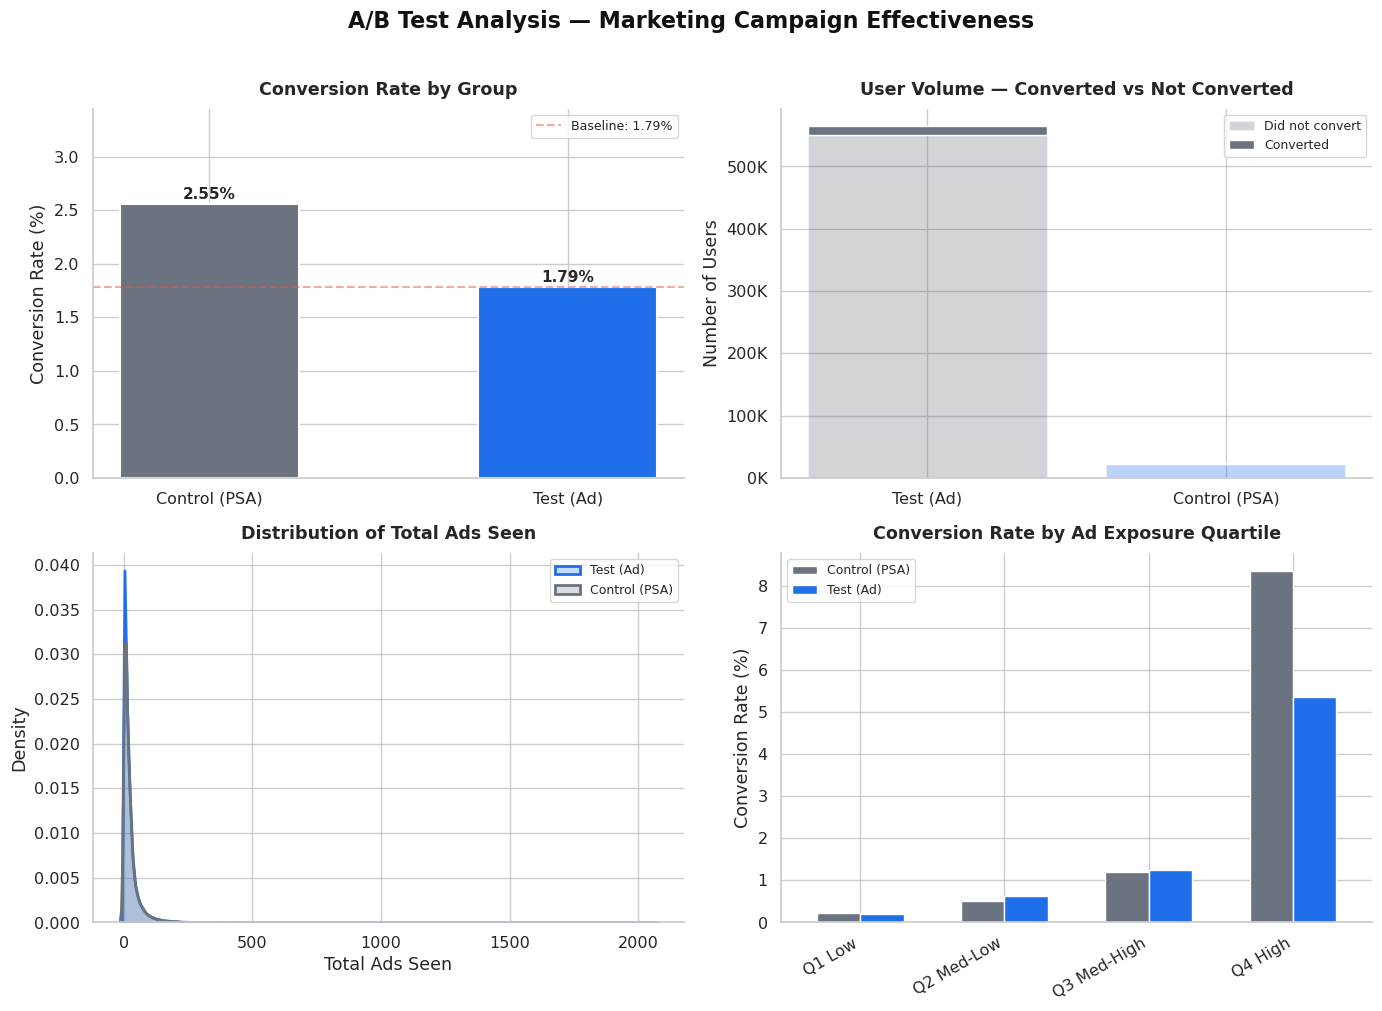

In [10]:
# FIGURE 1  — Executive Overview (2 × 2 grid)

fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle(
    "A/B Test Analysis — Marketing Campaign Effectiveness",
    fontsize=16, fontweight="bold", y=1.01, color="#111111"
)
 
#  1a: Conversion rate bar chart 

ax = axes[0, 0]
rates = summary["conversion_rate"].values
labels = ["Control (PSA)", "Test (Ad)"]
bars = ax.bar(labels, rates, color=[GRAY, BLUE], width=0.5, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.2f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_title("Conversion Rate by Group", fontweight="bold", pad=10)
ax.set_ylabel("Conversion Rate (%)")
ax.set_ylim(0, max(rates) * 1.35)
ax.axhline(psa_rate, color=CORAL, linestyle="--", alpha=0.5, label=f"Baseline: {psa_rate:.2f}%")
ax.legend(fontsize=9)
 
#  1b: Absolute user counts stacked bar

ax = axes[0, 1]
grp = summary.reset_index()
grp_labels = ["Control (PSA)" if g == "psa" else "Test (Ad)" for g in grp["test_group"]]
ax.bar(grp_labels, grp["non_conversions"], color=[GRAY, BLUE], alpha=0.3, label="Did not convert")
ax.bar(grp_labels, grp["conversions"],
       bottom=grp["non_conversions"], color=[GRAY, BLUE], label="Converted")
ax.set_title("User Volume — Converted vs Not Converted", fontweight="bold", pad=10)
ax.set_ylabel("Number of Users")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.legend(fontsize=9)
 
#  1c: KDE distribution of total ads seen

ax = axes[1, 0]
for grp_name, grp_col in [("Test (Ad)", BLUE), ("Control (PSA)", GRAY)]:
    key = "ad" if "Ad" in grp_name else "psa"
    sns.kdeplot(
        df[df["test_group"] == key]["total_ads"],
        ax=ax, color=grp_col, fill=True, alpha=0.25,
        linewidth=2, label=grp_name
    )
ax.set_title("Distribution of Total Ads Seen", fontweight="bold", pad=10)
ax.set_xlabel("Total Ads Seen")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
 
#  1d: Conversion by ad exposure quartile 
ax = axes[1, 1]
pivot_q = quartile_conv.pivot(index="ad_exposure_quartile", columns="test_group", values="conv_rate")
pivot_q.plot(kind="bar", ax=ax, color=[GRAY, BLUE], edgecolor="white", width=0.6)
ax.set_title("Conversion Rate by Ad Exposure Quartile", fontweight="bold", pad=10)
ax.set_ylabel("Conversion Rate (%)")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(["Control (PSA)", "Test (Ad)"], fontsize=9)
 
plt.tight_layout()

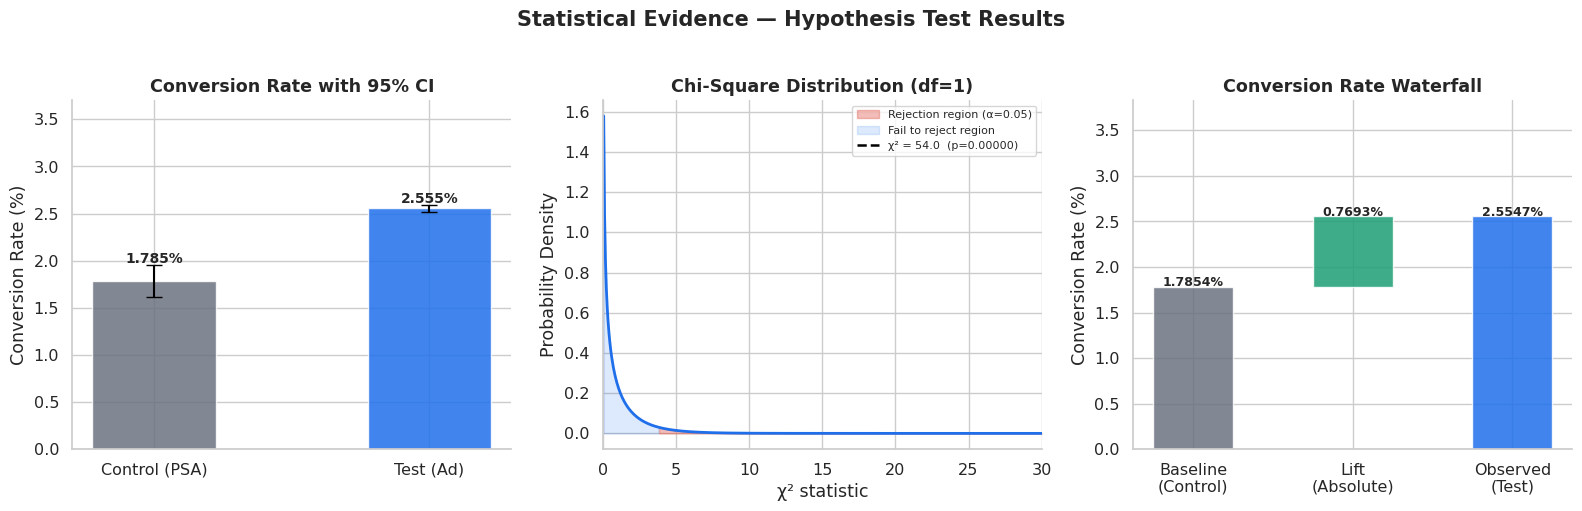

In [11]:
# FIGURE 2  — Statistical Evidence

fig2, axes = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle("Statistical Evidence — Hypothesis Test Results",
              fontsize=15, fontweight="bold", y=1.02)
 
#  2a: Conversion rate with 95% CI 

ax = axes[0]
groups_  = ["Control (PSA)", "Test (Ad)"]
rates_   = [psa_rate, ad_rate]
errs     = [
    z * np.sqrt(p_psa*(1-p_psa)/n_psa) * 100,
    z * np.sqrt(p_ad *(1-p_ad) /n_ad ) * 100,
]
colors_  = [GRAY, BLUE]
ax.bar(groups_, rates_, color=colors_, width=0.45, alpha=0.85, edgecolor="white")
ax.errorbar(groups_, rates_, yerr=errs, fmt="none", color="black", capsize=6, linewidth=1.5)
for i, (r, e) in enumerate(zip(rates_, errs)):
    ax.text(i, r + e + 0.02, f"{r:.3f}%", ha="center", fontweight="bold", fontsize=10)
ax.set_title("Conversion Rate with 95% CI", fontweight="bold")
ax.set_ylabel("Conversion Rate (%)")
ax.set_ylim(0, max(rates_) * 1.45)
 
#  2b: Chi-square distribution and critical region 
ax = axes[1]
x = np.linspace(0, 30, 500)
y = stats.chi2.pdf(x, df=1)
ax.plot(x, y, color=BLUE, linewidth=2)
crit = stats.chi2.ppf(0.95, df=1)
ax.fill_between(x, y, where=(x >= crit), color=CORAL, alpha=0.4, label=f"Rejection region (α=0.05)")
ax.fill_between(x, y, where=(x < crit),  color=BLUE,  alpha=0.15, label="Fail to reject region")
ax.axvline(chi2, color="black", linestyle="--", linewidth=1.8,
           label=f"χ² = {chi2:.1f}  (p={p_value:.5f})")
ax.set_title("Chi-Square Distribution (df=1)", fontweight="bold")
ax.set_xlabel("χ² statistic")
ax.set_ylabel("Probability Density")
ax.legend(fontsize=8)
ax.set_xlim(0, 30)
 
#  2c: Lift waterfall 

ax = axes[2]
waterfall_vals = [psa_rate, lift, ad_rate]
waterfall_labels = ["Baseline\n(Control)", "Lift\n(Absolute)", "Observed\n(Test)"]
bottoms = [0, psa_rate, 0]
wcolors = [GRAY, GREEN, BLUE]
for i, (val, bot, col, lab) in enumerate(
        zip(waterfall_vals, bottoms, wcolors, waterfall_labels)):
    ax.bar(i, val, bottom=bot, color=col, width=0.5, edgecolor="white", alpha=0.85)
    ax.text(i, bot + val + 0.01, f"{val:.4f}%", ha="center", fontweight="bold", fontsize=9)
ax.set_xticks(range(3))
ax.set_xticklabels(waterfall_labels)
ax.set_title("Conversion Rate Waterfall", fontweight="bold")
ax.set_ylabel("Conversion Rate (%)")
ax.set_ylim(0, ad_rate * 1.5)
 
plt.tight_layout()

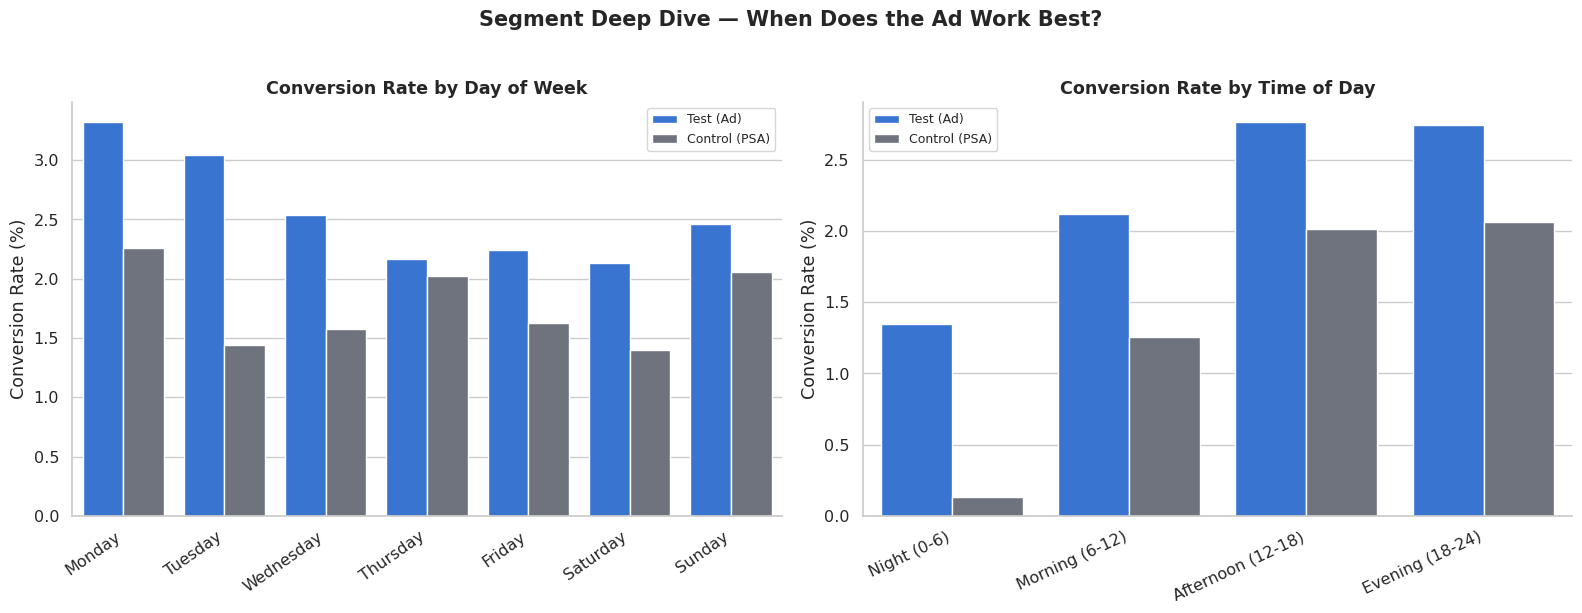

In [12]:
# FIGURE 3  — Segment Deep Dive

fig3, axes = plt.subplots(1, 2, figsize=(16, 6))
fig3.suptitle("Segment Deep Dive — When Does the Ad Work Best?",
              fontsize=15, fontweight="bold", y=1.02)
 
#  3a: Conversion by day of week 

ax = axes[0]
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_conv_pivot = day_conv.copy()
day_conv_pivot["group_label"] = day_conv_pivot["test_group"].map(
    {"ad": "Test (Ad)", "psa": "Control (PSA)"}
)
sns.barplot(
    data=day_conv_pivot, x="most_ads_day", y="conv_rate",
    hue="group_label", palette={"Test (Ad)": BLUE, "Control (PSA)": GRAY},
    order=day_order, ax=ax, edgecolor="white"
)
ax.set_title("Conversion Rate by Day of Week", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Conversion Rate (%)")
ax.set_xticklabels(day_order, rotation=35, ha="right")
ax.legend(title="", fontsize=9)
 
#  3b: Conversion by time of day 
ax = axes[1]
hour_conv_plot = hour_conv.copy()
hour_conv_plot["group_label"] = hour_conv_plot["test_group"].map(
    {"ad": "Test (Ad)", "psa": "Control (PSA)"}
)
hour_order = ["Night (0-6)", "Morning (6-12)", "Afternoon (12-18)", "Evening (18-24)"]
sns.barplot(
    data=hour_conv_plot, x="hour_bucket", y="conv_rate",
    hue="group_label", palette={"Test (Ad)": BLUE, "Control (PSA)": GRAY},
    order=hour_order, ax=ax, edgecolor="white"
)
ax.set_title("Conversion Rate by Time of Day", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Conversion Rate (%)")
ax.set_xticklabels(hour_order, rotation=25, ha="right")
ax.legend(title="", fontsize=9)
 
plt.tight_layout()

# DIFF-IN-DIFF CAUSAL INFERENCE

In [13]:
"""
Diff-in-Diff logic applied to ad exposure quartiles:
  Pre-period  proxy → Q1 (low ad exposure, early campaign stage)
  Post-period proxy → Q4 (high ad exposure, mature campaign stage)
"""

'\nDiff-in-Diff logic applied to ad exposure quartiles:\n  Pre-period  proxy → Q1 (low ad exposure, early campaign stage)\n  Post-period proxy → Q4 (high ad exposure, mature campaign stage)\n'

In [14]:
did_data = df[df["test_group"].isin(["ad", "psa"])].copy()
did_data["period"] = did_data["ad_exposure_quartile"].map(
    {"Q1 Low": "pre", "Q2 Med-Low": "pre",
     "Q3 Med-High": "post", "Q4 High": "post"}
)
did_data = did_data.dropna(subset=["period"])
 
did_summary = (
    did_data.groupby(["test_group", "period"])["converted"]
            .mean().reset_index()
)
 
pre_ad   = did_summary.query("test_group=='ad'  and period=='pre'")["converted"].values[0]
post_ad  = did_summary.query("test_group=='ad'  and period=='post'")["converted"].values[0]
pre_psa  = did_summary.query("test_group=='psa' and period=='pre'")["converted"].values[0]
post_psa = did_summary.query("test_group=='psa' and period=='post'")["converted"].values[0]
 
did_estimate = (post_ad - pre_ad) - (post_psa - pre_psa)
 
print(f"\n  Ad  group  — pre : {pre_ad*100:.4f}%  post : {post_ad*100:.4f}%")
print(f"  PSA group  — pre : {pre_psa*100:.4f}%  post : {post_psa*100:.4f}%")
print(f"\n  DiD estimate (causal effect) : {did_estimate*100:.4f} pp")
print(f"  Interpretation: After controlling for baseline trends, the ad")
print(f"  caused a {abs(did_estimate*100):.4f} pp {'increase' if did_estimate > 0 else 'decrease'} in conversion rate.")


  Ad  group  — pre : 0.3761%  post : 4.8055%
  PSA group  — pre : 0.4047%  post : 3.3782%

  DiD estimate (causal effect) : 1.4559 pp
  Interpretation: After controlling for baseline trends, the ad
  caused a 1.4559 pp increase in conversion rate.


In [15]:
# DiD visualisation

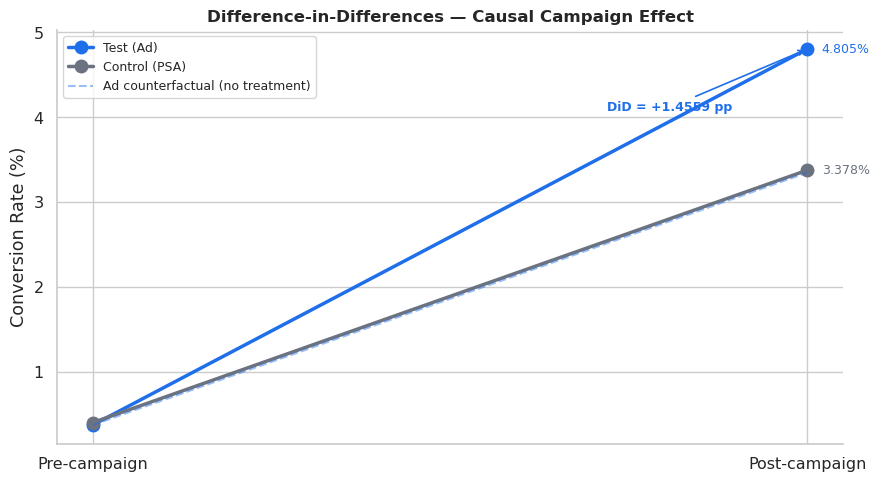

In [16]:
fig4, ax = plt.subplots(figsize=(9, 5))
for grp, col, lbl in [("ad", BLUE, "Test (Ad)"), ("psa", GRAY, "Control (PSA)")]:
    sub = did_summary[did_summary["test_group"] == grp].set_index("period")
    pre_val  = sub.loc["pre",  "converted"] * 100
    post_val = sub.loc["post", "converted"] * 100
    ax.plot(["Pre-campaign", "Post-campaign"], [pre_val, post_val],
            marker="o", markersize=9, linewidth=2.5, color=col, label=lbl)
    ax.text(1.02, post_val, f"{post_val:.3f}%", va="center", color=col, fontsize=9)
 
# Counterfactual dashed line for ad group
counterfactual = pre_ad*100 + (post_psa - pre_psa)*100
ax.plot(["Pre-campaign", "Post-campaign"], [pre_ad*100, counterfactual],
        linestyle="--", color=BLUE, alpha=0.45, label="Ad counterfactual (no treatment)")
ax.annotate(
    f"DiD = {did_estimate*100:+.4f} pp",
    xy=(1, post_ad*100), xytext=(0.72, (post_ad*100 + counterfactual)/2),
    fontsize=9, color=BLUE, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=BLUE, lw=1.2)
)
ax.set_title("Difference-in-Differences — Causal Campaign Effect",
             fontweight="bold", fontsize=12)
ax.set_ylabel("Conversion Rate (%)")
ax.legend(fontsize=9)
plt.tight_layout()

In [17]:
df = pd.read_csv("marketing_AB.csv") 
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_") 
df["converted"] = df["converted"].astype(int) 

# Summary table 

summary = df.groupby("test_group")["converted"].agg(
    total_users="count", 
    conversions="sum"
).assign(conversion_rate=lambda x: x["conversions"]/x["total_users"]*100).reset_index() 
summary["group_label"] = summary["test_group"].map({"ad":"Test (Ad)","psa":"Control (PSA)"}) 
summary.to_csv("tableau_summary.csv", index=False) 

# Day segmentation 

day = df.groupby(["most_ads_day","test_group"])["converted"].mean().reset_index() 
day.columns = ["day","group","conversion_rate"] 
day["conversion_rate"] *= 100 
day["group_label"] = day["group"].map({"ad":"Test (Ad)","psa":"Control (PSA)"}) 
day.to_csv("tableau_day.csv", index=False) 

# Hour segmentation

df["hour_bucket"] = pd.cut(df["most_ads_hour"],bins=[0,6,12,18,24], labels=["Night","Morning","Afternoon","Evening"],right=False) 
hour = df.groupby(["hour_bucket","test_group"])["converted"].mean().reset_index() 
hour.columns = ["hour","group","conversion_rate"] 
hour["conversion_rate"] *= 100 

# Fixed: Added line break here

hour["group_label"] = hour["group"].map({"ad":"Test (Ad)","psa":"Control (PSA)"}) 
hour.to_csv("tableau_hour.csv", index=False) 
print("3 CSV files exported successfully")

3 CSV files exported successfully
